In [60]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import optimize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Librerias cargadas")

Librerias cargadas


In [61]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("utilizamos :", device)

utilizamos : cpu


In [62]:

data = pd.read_csv(
    "australian.dat",
    header=None,
    sep=r"\s+"
)

print("Dataset cargado ")
print("Dimensiones del dataset:")
print(data.shape)
print("\nPrimeras filas:")
display(data.head())

Dataset cargado 
Dimensiones del dataset:
(690, 15)

Primeras filas:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [63]:

data.columns = [
    "A1","A2","A3","A4","A5",
    "A6","A7","A8","A9","A10",
    "A11","A12","A13","A14",
    "target"
]

print("Columnas asignadas correctamente.")
print(data.columns.tolist())

Columnas asignadas correctamente.
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'target']


In [64]:

print("\nTipos de datos:")
print(data.dtypes)

print("\nEstadísticas básicas:")
display(data.describe())

print("\nDistribución de clases:")
print(data['target'].value_counts())


Tipos de datos:
A1          int64
A2        float64
A3        float64
A4          int64
A5          int64
A6          int64
A7        float64
A8          int64
A9          int64
A10         int64
A11         int64
A12         int64
A13         int64
A14         int64
target      int64
dtype: object

Estadísticas básicas:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,target
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000



Distribución de clases:
target
0    383
1    307
Name: count, dtype: int64


In [65]:

print("Valores nulos por columna:")
print(data.isnull().sum())
print("\nTotal de nulos:", data.isnull().sum().sum())

Valores nulos por columna:
A1        0
A2        0
A3        0
A4        0
A5        0
A6        0
A7        0
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14       0
target    0
dtype: int64

Total de nulos: 0


In [66]:

features = [
    "A1","A2","A3","A4","A5",
    "A6","A7","A8","A9","A10",
    "A11","A12","A13","A14"
]

target = "target"

X = data[features].values.astype(np.float64)
y = data[target].values.astype(np.float64)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Clases únicas:", np.unique(y))

Forma de X:

 (690, 14)
Forma de y: (690,)
Clases únicas: [0. 1.]


In [67]:

def normalizar(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalizar(X)

print("datos normalizados ")
print("media (debe ser ~0):", np.round(X_norm.mean(axis=0), 3))

datos normalizados 
media (debe ser ~0): [ 0.  0.  0.  0. -0.  0.  0. -0. -0. -0.  0. -0.  0.  0.]


In [68]:

split = int(len(X_norm) * 0.75)

X_train = X_norm[:split]
y_train = y[:split]

X_test = X_norm[split:]
y_test = y[split:]

print("Train:", X_train.shape, f"({len(X_train)/len(X_norm)*100:.0f}%)")
print("Test: ", X_test.shape,  f"({len(X_test)/len(X_norm)*100:.0f}%)")

Train: (517, 14) (75%)
Test:  (173, 14) (25%)


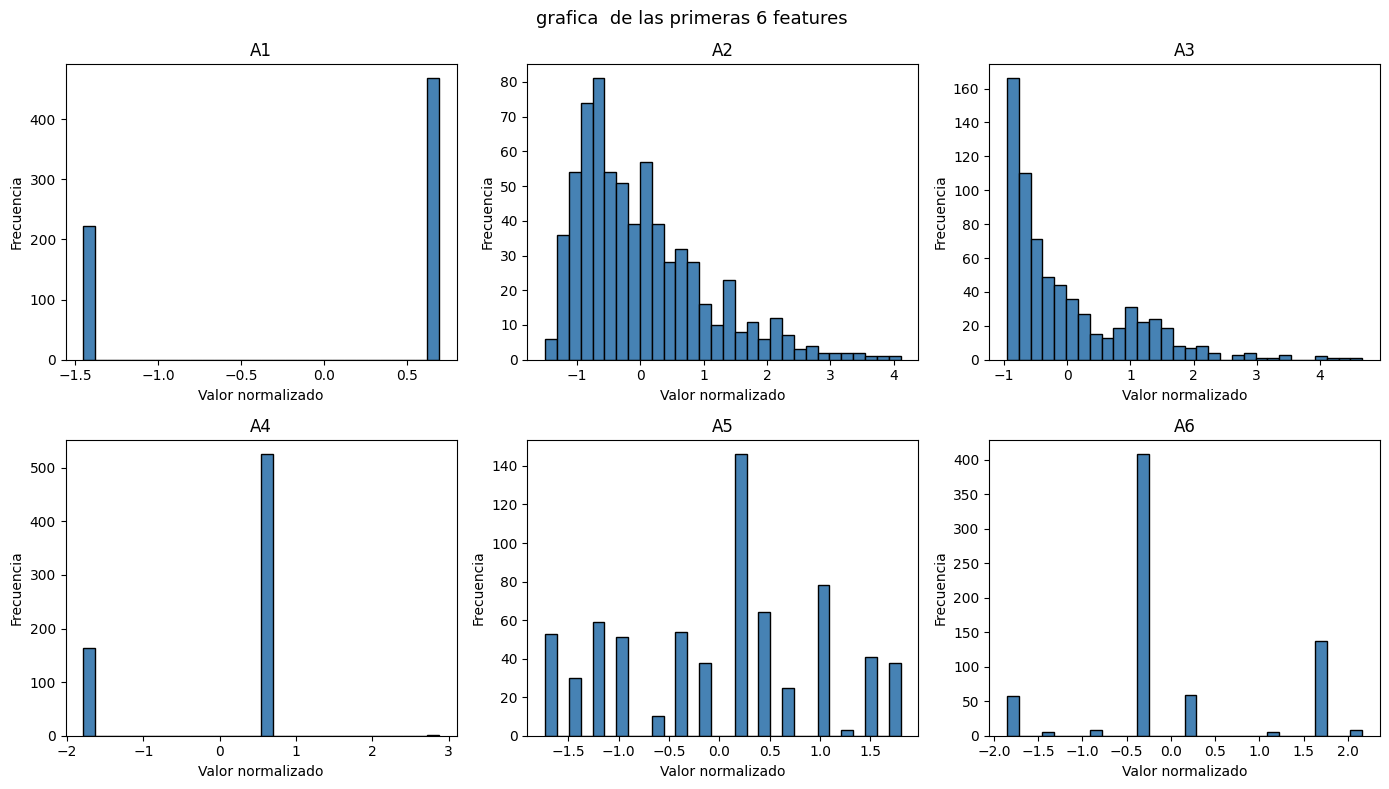

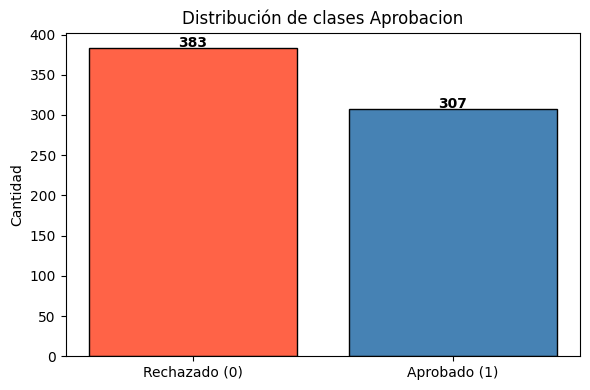

In [69]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].hist(X_norm[:, i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(features[i])
    axes[i].set_xlabel("Valor normalizado")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("grafica  de las primeras 6 features ", fontsize=13)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
clases, conteos = np.unique(y, return_counts=True)
plt.bar(['Rechazado (0)', 'Aprobado (1)'], conteos, color=['tomato','steelblue'], edgecolor='black')
plt.title("Distribución de clases Aprobacion")
plt.ylabel("Cantidad")
for i, v in enumerate(conteos):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    h = sigmoid(X.dot(theta))
    J = (1/m) * (-y.dot(np.log(h + 1e-10)) - (1-y).dot(np.log(1 - h + 1e-10)))
    J += (lambda_ / (2*m)) * np.sum(theta[1:]**2)
    grad = (1/m) * X.T.dot(h - y)
    grad[1:] += (lambda_ / m) * theta[1:]
    return J, grad

X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b  = np.c_[np.ones(X_test.shape[0]),  X_test]

theta_init = np.zeros(X_train_b.shape[1])

result = optimize.minimize(
    lrCostFunction,
    theta_init,
    args=(X_train_b, y_train, 0.01),
    method='TNC',
    jac=True,
    options={'maxiter': 500}
)

theta_opt = result.x
print("Optimización completada.")
print("Costo final:", round(result.fun, 6))

Optimización completada.
Costo final: 0.313165


C:\Users\erick\AppData\Local\Temp\ipykernel_10944\2859453627.py:18: OptimizeWarning: Unknown solver options: maxiter
  result = optimize.minimize(


  Resultados  Regresion  
  Accuracy entrenamiento: 87.04%
  Accuracy prueba:        87.28%

Reporte de clasificación (test):
              precision    recall  f1-score   support

   Rechazado       0.92      0.86      0.89       101
    Aprobado       0.82      0.89      0.85        72

    accuracy                           0.87       173
   macro avg       0.87      0.88      0.87       173
weighted avg       0.88      0.87      0.87       173



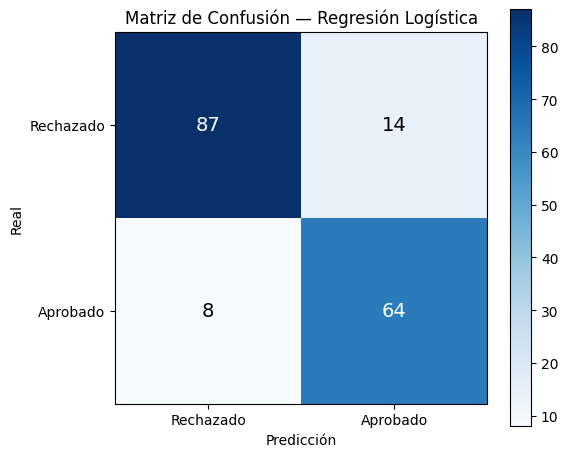

In [71]:

pred_train_lr = (sigmoid(X_train_b.dot(theta_opt)) >= 0.5).astype(int)
pred_test_lr  = (sigmoid(X_test_b.dot(theta_opt))  >= 0.5).astype(int)

acc_train_lr = accuracy_score(y_train, pred_train_lr)
acc_test_lr  = accuracy_score(y_test,  pred_test_lr)


print("  Resultados  Regresion  ")
print(f"  Accuracy entrenamiento: {acc_train_lr*100:.2f}%")
print(f"  Accuracy prueba:        {acc_test_lr*100:.2f}%")
print()
print("Reporte de clasificación (test):")
print(classification_report(y_test, pred_test_lr, target_names=['Rechazado','Aprobado']))

cm_lr = confusion_matrix(y_test, pred_test_lr)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_lr, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1]); ax.set_xticklabels(['Rechazado','Aprobado'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Rechazado','Aprobado'])
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title("Matriz de Confusión — Regresión Logística")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_lr[i,j]), ha='center', va='center',
                color='white' if cm_lr[i,j] > cm_lr.max()/2 else 'black', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\erick\AppData\Local\Temp\ipykernel_10944\3089137805.py:5: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(


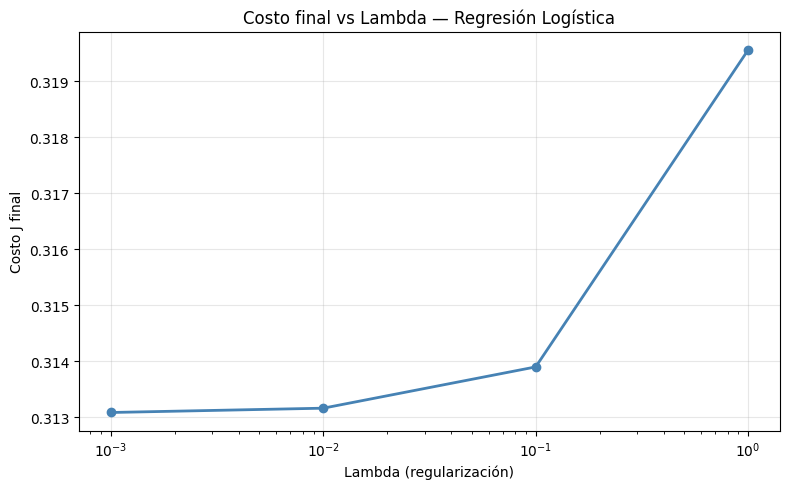

In [72]:

lambdas = [0.001, 0.01, 0.1, 1.0]
costos  = []

for lam in lambdas:
    res = optimize.minimize(
        lrCostFunction,
        np.zeros(X_train_b.shape[1]),
        args=(X_train_b, y_train, lam),
        method='TNC',
        jac=True,
        options={'maxiter': 200}
    )
    costos.append(res.fun)

plt.figure(figsize=(8, 5))
plt.plot(lambdas, costos, 'o-', color='steelblue', lw=2)
plt.xscale('log')
plt.xlabel("Lambda (regularización)")
plt.ylabel("Costo J final")
plt.title("Costo final vs Lambda — Regresión Logística")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:

class CreditDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset_train = CreditDataset(X_train, y_train)
dataset_test  = CreditDataset(X_test,  y_test)

dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
dataloader_test  = DataLoader(dataset_test,  batch_size=32, shuffle=False)

print("Dataset train:", len(dataset_train), "muestras")
print("Dataset test: ", len(dataset_test),  "muestras")

Dataset train: 517 muestras
Dataset test:  173 muestras


In [74]:

class RedClasificacion(nn.Module):
    def __init__(self, n_entradas):
        super(RedClasificacion, self).__init__()
        self.capa1  = nn.Linear(n_entradas, 64)
        self.capa2  = nn.Linear(64, 32)
        self.capa3  = nn.Linear(32, 16)
        self.salida = nn.Linear(16, 1)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.dropout(self.relu(self.capa1(x)))
        x = self.dropout(self.relu(self.capa2(x)))
        x = self.dropout(self.relu(self.capa3(x)))
        x = self.sigmoid(self.salida(x))
        return x.squeeze(-1)

modelo = RedClasificacion(n_entradas=X_train.shape[1]).to(device)
print(modelo)
print(f"Parámetros entrenables: {sum(p.numel() for p in modelo.parameters()):,}")

RedClasificacion(
  (capa1): Linear(in_features=14, out_features=64, bias=True)
  (capa2): Linear(in_features=64, out_features=32, bias=True)
  (capa3): Linear(in_features=32, out_features=16, bias=True)
  (salida): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.2, inplace=False)
)
Parámetros entrenables: 3,585


In [75]:

criterio    = nn.BCELoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

EPOCHS    = 100
CHECKPOINT = './australian_mejor_modelo.pt'

hist_train = []
hist_test  = []
hist_acc   = []
mejor_acc  = 0.0

for epoca in range(1, EPOCHS + 1):

    modelo.train()
    c_train = []
    for x_b, y_b in dataloader_train:
        y_pred = modelo(x_b)
        loss   = criterio(y_pred, y_b)
        c_train.append(loss.item())
        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

    modelo.eval()
    c_test = []
    preds, labels = [], []
    with torch.no_grad():
        for x_b, y_b in dataloader_test:
            y_pred = modelo(x_b)
            loss   = criterio(y_pred, y_b)
            c_test.append(loss.item())
            preds.extend((y_pred >= 0.5).float().cpu().numpy())
            labels.extend(y_b.cpu().numpy())

    loss_tr = np.mean(c_train)
    loss_te = np.mean(c_test)
    acc_te  = accuracy_score(labels, preds)

    hist_train.append(loss_tr)
    hist_test.append(loss_te)
    hist_acc.append(acc_te)

    if acc_te > mejor_acc:
        mejor_acc = acc_te
        torch.save(modelo.state_dict(), CHECKPOINT)

    if not epoca % 10:
        print(f"Época {epoca:3d}/{EPOCHS} | Train Loss: {loss_tr:.4f} | Val Loss: {loss_te:.4f} | Acc: {acc_te:.4f}")

modelo.load_state_dict(torch.load(CHECKPOINT, weights_only=True))
print(f"\nMejor accuracy: {mejor_acc*100:.2f}%")

Época  10/100 | Train Loss: 0.3353 | Val Loss: 0.3247 | Acc: 0.8497
Época  20/100 | Train Loss: 0.2780 | Val Loss: 0.3304 | Acc: 0.8728
Época  30/100 | Train Loss: 0.2401 | Val Loss: 0.3385 | Acc: 0.8671
Época  40/100 | Train Loss: 0.2221 | Val Loss: 0.3493 | Acc: 0.8671
Época  50/100 | Train Loss: 0.2161 | Val Loss: 0.3689 | Acc: 0.8728
Época  60/100 | Train Loss: 0.1973 | Val Loss: 0.3939 | Acc: 0.8671
Época  70/100 | Train Loss: 0.1955 | Val Loss: 0.4068 | Acc: 0.8671
Época  80/100 | Train Loss: 0.1932 | Val Loss: 0.4174 | Acc: 0.8613
Época  90/100 | Train Loss: 0.1788 | Val Loss: 0.4518 | Acc: 0.8613
Época 100/100 | Train Loss: 0.1909 | Val Loss: 0.4422 | Acc: 0.8671

Mejor accuracy: 88.44%


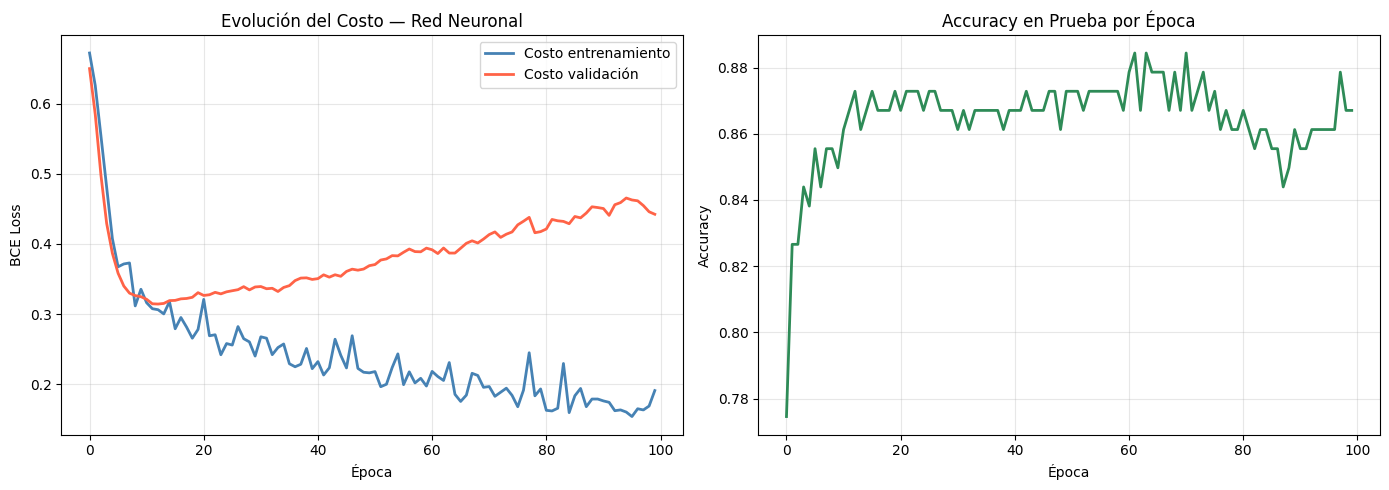

In [76]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_train, label='Costo entrenamiento', color='steelblue', lw=2)
axes[0].plot(hist_test,  label='Costo validación',    color='tomato',    lw=2)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Evolución del Costo — Red Neuronal")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_acc, color='seagreen', lw=2)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy en Prueba por Época")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

  RESULTADOS — RED NEURONAL
  Accuracy prueba:  88.44%

Reporte de clasificación (test):
              precision    recall  f1-score   support

   Rechazado       0.88      0.93      0.90       101
    Aprobado       0.89      0.82      0.86        72

    accuracy                           0.88       173
   macro avg       0.89      0.88      0.88       173
weighted avg       0.88      0.88      0.88       173



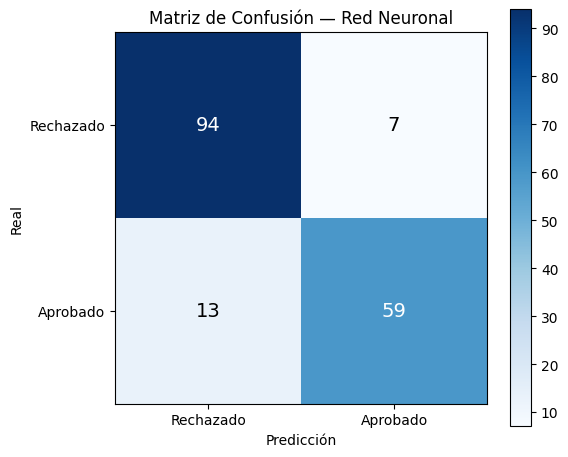

In [77]:

modelo.eval()
preds_nn, labels_nn = [], []

with torch.no_grad():
    for x_b, y_b in dataloader_test:
        y_pred = modelo(x_b)
        preds_nn.extend((y_pred >= 0.5).float().cpu().numpy())
        labels_nn.extend(y_b.cpu().numpy())

acc_nn = accuracy_score(labels_nn, preds_nn)

print("  RESULTADOS — RED NEURONAL")
print(f"  Accuracy prueba:  {acc_nn*100:.2f}%")
print()
print("Reporte de clasificación (test):")
print(classification_report(labels_nn, preds_nn, target_names=['Rechazado','Aprobado']))

cm_nn = confusion_matrix(labels_nn, preds_nn)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_nn, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1]); ax.set_xticklabels(['Rechazado','Aprobado'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Rechazado','Aprobado'])
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title("Matriz de Confusión — Red Neuronal")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_nn[i,j]), ha='center', va='center',
                color='white' if cm_nn[i,j] > cm_nn.max()/2 else 'black', fontsize=14)
plt.tight_layout()
plt.show()

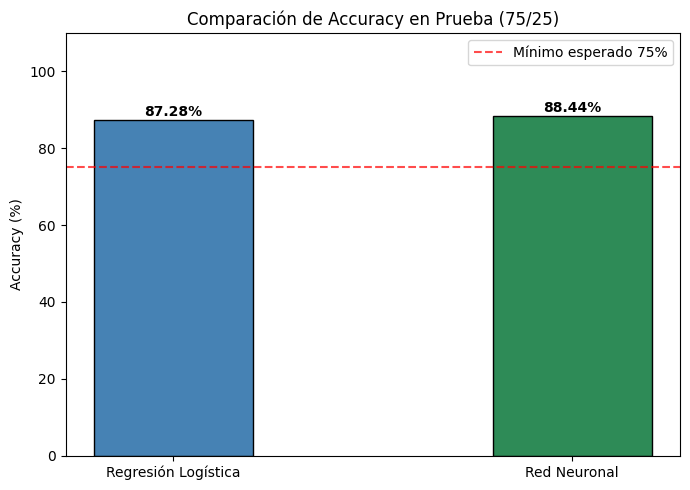

 RESUMEN COMPARATIVO
  Regresión Logística — Accuracy prueba: 87.28%
  Red Neuronal        — Accuracy prueba: 88.44%
  Mejor modelo: Red Neuronal


In [78]:

modelos  = ['Regresión Logística', 'Red Neuronal']
acc_vals = [acc_test_lr * 100, acc_nn * 100]

plt.figure(figsize=(7, 5))
barras = plt.bar(modelos, acc_vals,
                 color=['steelblue', 'seagreen'], edgecolor='black', width=0.4)
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("Comparación de Accuracy en Prueba (75/25)")
plt.axhline(75, color='red', linestyle='--', alpha=0.7, label='Mínimo esperado 75%')
for bar, val in zip(barras, acc_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.2f}%', ha='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(" RESUMEN COMPARATIVO")
print(f"  Regresión Logística — Accuracy prueba: {acc_test_lr*100:.2f}%")
print(f"  Red Neuronal        — Accuracy prueba: {acc_nn*100:.2f}%")
mejor = "Regresión Logística" if acc_test_lr >= acc_nn else "Red Neuronal"
print(f"  Mejor modelo: {mejor}")
